# Email Spam Detection with Machine Learning
**OIBSIP Data Science Track — Task 4**

Objective: build an NLP binary classifier that distinguishes spam from legitimate
(ham) messages.

**Note on data:** built offline, so the real "SMS Spam Collection" dataset (Kaggle /
UCI) could not be downloaded. A synthetic corpus of spam- and ham-style messages is
generated below from templates with randomised wording, at a similar ~13% spam class
balance to the real dataset, so the full pipeline runs end-to-end. Swap in the real
`spam.csv` (columns `label`, `message`) before submission — no other code changes
are needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import re

rng = np.random.default_rng(11)
sns.set_style("whitegrid")

spam_templates = [
    "WIN a free {prize} now! Click {link} to claim your prize before it expires",
    "URGENT: your account has a {prize} waiting, call {phone} immediately",
    "Congratulations! You have been selected to win a {prize}. Reply YES to claim",
    "Limited time offer: get {prize} for FREE, click {link} now, hurry!!!",
    "You won a lottery of $1000. Send your bank details to claim your {prize}",
    "FREE entry to win {prize}! Text WIN to {phone} now, offer ends today",
    "Cash prize alert! Claim your {prize} instantly at {link}, no cost involved",
    "Your loan of $5000 is approved, call {phone} now to receive the {prize}",
]
ham_templates = [
    "Hey, are we still meeting for {activity} tomorrow at {time}?",
    "Can you send me the notes from {activity} class, I missed it",
    "Don't forget to pick up milk on your way home from {activity}",
    "Happy birthday! Hope you have a great {activity} today",
    "Let's catch up over {activity} sometime this week, are you free?",
    "The meeting about {activity} got moved to {time}, see you there",
    "Thanks for helping me with {activity} yesterday, really appreciate it",
    "I'll be a bit late for {activity}, stuck in traffic, see you at {time}",
]
prizes = ["iPhone", "gift card", "vacation package", "cash reward", "voucher"]
phones = ["09051234567", "07700900123", "08001234567"]
links = ["bit.ly/claim1", "bit.ly/win2", "shorturl.at/prize"]
activities = ["lunch", "the project", "dinner", "the gym", "study group", "the movie"]
times = ["6pm", "noon", "3:30", "tomorrow morning", "8am"]

def fill(template):
    return template.format(
        prize=rng.choice(prizes), phone=rng.choice(phones), link=rng.choice(links),
        activity=rng.choice(activities), time=rng.choice(times),
    )

n_ham, n_spam = 700, 100
messages = [fill(rng.choice(ham_templates)) for _ in range(n_ham)]
labels = ["ham"] * n_ham
messages += [fill(rng.choice(spam_templates)) for _ in range(n_spam)]
labels += ["spam"] * n_spam

df = pd.DataFrame({"label": labels, "message": messages}).sample(frac=1, random_state=1).reset_index(drop=True)
print(df.head())
print("\nShape:", df.shape)

  label                                            message
0   ham  I'll be a bit late for study group, stuck in t...
1   ham  The meeting about study group got moved to tom...
2   ham  Don't forget to pick up milk on your way home ...
3  spam  You won a lottery of $1000. Send your bank det...
4   ham  Hey, are we still meeting for lunch tomorrow a...

Shape: (800, 2)


## 1. Class Distribution

label
ham     700
spam    100
Name: count, dtype: int64

Spam percentage: 12.5%


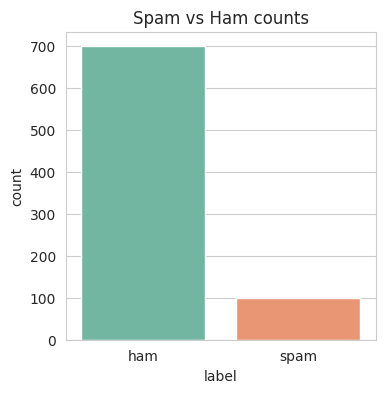

In [2]:
counts = df["label"].value_counts()
print(counts)
print("\nSpam percentage: {:.1f}%".format(100 * counts["spam"] / len(df)))

plt.figure(figsize=(4, 4))
sns.barplot(x=counts.index, y=counts.values, palette="Set2")
plt.title("Spam vs Ham counts")
plt.ylabel("count")
plt.show()

## 2. Text Preprocessing

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
print(df[["message", "clean_message"]].head())

                                             message                                      clean_message
0  I'll be a bit late for study group, stuck in t...  i ll be a bit late for study group stuck in tr...
1  The meeting about study group got moved to tom...  the meeting about study group got moved to tom...
2  Don't forget to pick up milk on your way home ...  don t forget to pick up milk on your way home ...
3  You won a lottery of $1000. Send your bank det...  you won a lottery of send your bank details to...
4  Hey, are we still meeting for lunch tomorrow a...  hey are we still meeting for lunch tomorrow at...


## 3. Feature Extraction (TF-IDF)

In [4]:
# TF-IDF weights each word by how often it appears in a message (term frequency)
# balanced against how common it is across all messages (inverse document
# frequency), so distinctive words like "free" or "win" score higher than common
# words like "the" or "you".
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print("TF-IDF matrix shape (train):", X_train.shape)

TF-IDF matrix shape (train): (640, 85)


## 4. Model Training and Evaluation

In [5]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=300),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label="spam")
    rec = recall_score(y_test, preds, pos_label="spam")
    f1 = f1_score(y_test, preds, pos_label="spam")
    results[name] = (acc, preds)
    print(f"\n=== {name} ===")
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print(classification_report(y_test, preds))


=== Multinomial Naive Bayes ===
Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       140
        spam       1.00      1.00      1.00        20

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


=== Logistic Regression ===
Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       140
        spam       1.00      1.00      1.00        20

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



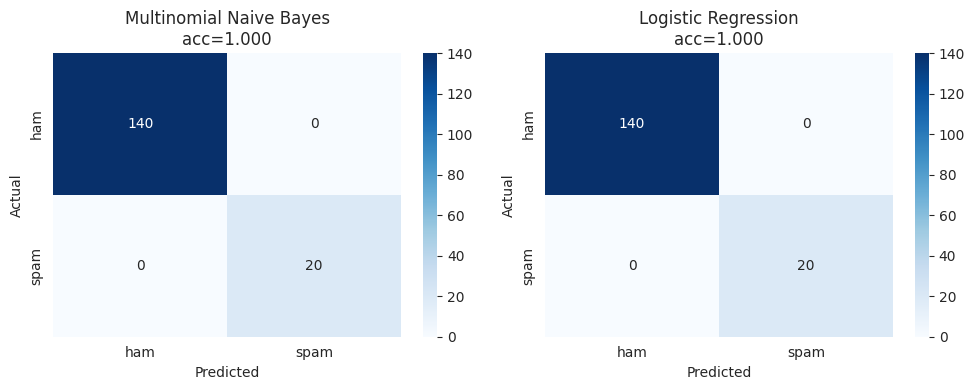

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, (acc, preds)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, preds, labels=["ham", "spam"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    ax.set_title(f"{name}\nacc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**Why recall matters here:** for spam detection, recall on the "spam" class measures
how many actual spam messages were correctly caught. Missing spam (a false negative)
lets a scam through to the user's inbox, which is usually worse than the milder
inconvenience of a false positive (a real message wrongly flagged as spam) — so
recall is often prioritised over precision, even though a very low precision would
also hurt trust in the filter.